In [1]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(patchwork))
suppressPackageStartupMessages(library(showtext))
suppressPackageStartupMessages(library(reshape2))
showtext_auto()

In [2]:
# load data
ct_anno = read.table('xxx/PaaSc_Data/Traits/ct_anno.txt',sep = '\t', header=T)
meta = read.table('xxx/PaaSc_Data/TMS/TMS_facs_selected_metadata.tsv',sep = '\t', header=T)
PaaSc = read.table('xxx/PaaSc_Data/TMS/TMS_facs_selected_alltraits_PaaSc_score.tsv')
CelliD = read.table('xxx/PaaSc_Data/TMS/TMS_facs_selected_alltraits_CelliD_score.tsv')
GSDensity = read.table('xxx/PaaSc_Data/TMS/TMS_facs_selected_alltraits_GSDensity_score.tsv')

Sup Fig5A

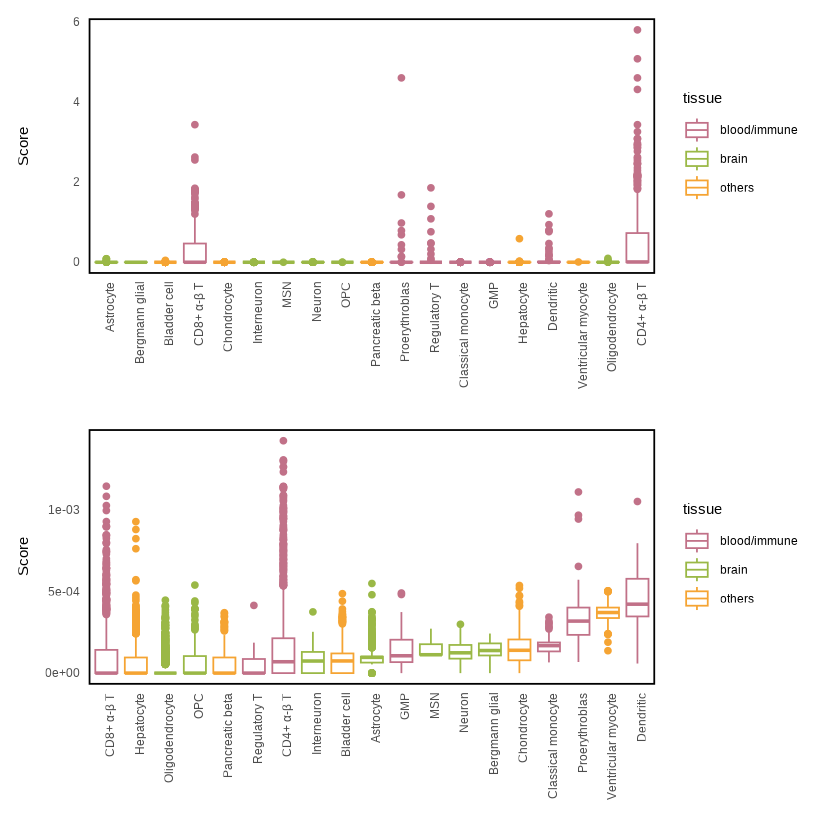

In [3]:
generate_boxplot <- function(df, method) {
    df = df %>% mutate(celltype=ct_anno$abbreviation[match(meta$cell_ontology_class, ct_anno$CellType)])
    df$celltype <- reorder(df$celltype, df[['UKB_460K.blood_LYMPHOCYTE_COUNT']], FUN = median, decreasing = TRUE)
    df$tissue <- ct_anno$tissue[match(df$celltype, ct_anno$abbreviation)]
    ggplot(df, aes(x = celltype, y = UKB_460K.blood_LYMPHOCYTE_COUNT,color= tissue)) +
      geom_boxplot() +
      guides(title = NULL)+
      labs(x = NULL, y = 'Score', title = NULL) +
      scale_color_manual(values = c("blood/immune" = "#C17188", "brain" = "#9AB846", "others" = "#F5A433")) +
      theme_minimal() +
      theme(
        axis.text.x = element_text( angle = 90,hjust = 1, vjust = 1),
        panel.background = element_blank(),
        plot.background = element_blank(),
        panel.border = element_rect(fill = NA, linewidth = 1),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank()
      ) 
}    

supFig5A = generate_boxplot(CelliD, 'CelliD') / generate_boxplot(GSDensity, 'GSDensity')
supFig5A

##### Sup Fig5B

No id variables; using all as measure variables

Warning message:
“Removed 1082 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 1082 rows containing non-finite outside the scale range (`stat_density()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_bar()`).”


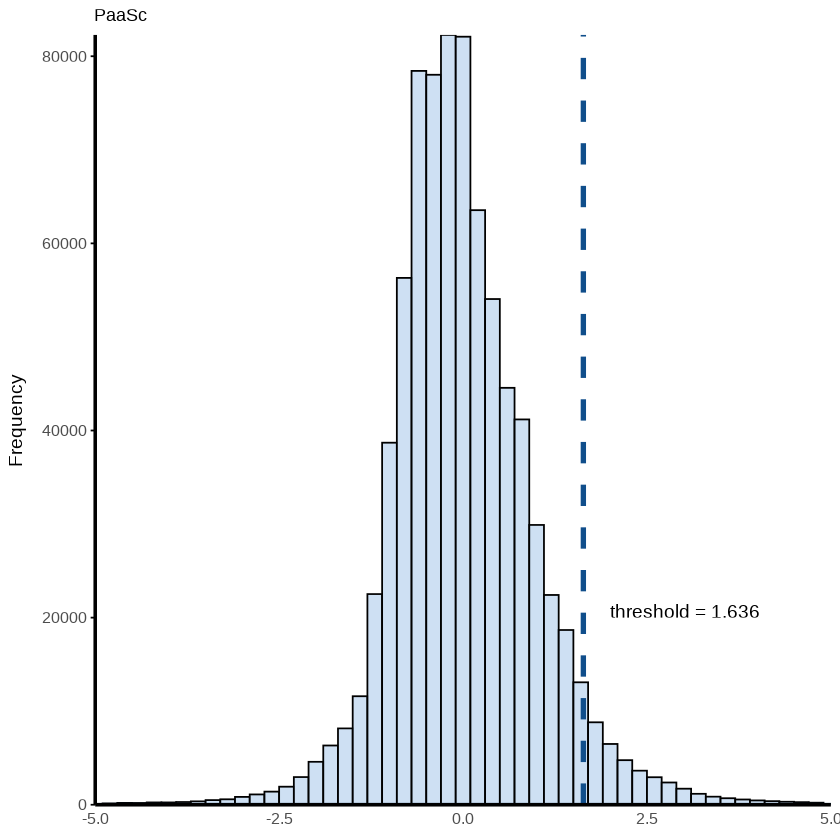

In [4]:
PaaSc_all=melt(PaaSc)
threshold = quantile(PaaSc_all$value, 0.95)
FigPaaSc <- ggplot(PaaSc_all, aes(x = value)) +
              geom_histogram(aes(y = after_stat(count)), 
                             binwidth = 0.2, 
                             fill = "slategray2", 
                             color = "black", 
                             alpha = 0.7, 
                             position = "identity") + 
              geom_density(color = "dodgerblue4", linewidth = 1) + 
              labs(title = 'PaaSc', x = NULL, y = "Frequency") + 
              annotate("text", x = 2, y = 20000, label = paste0("threshold = ", signif(threshold, 4)), hjust = 0, vjust = 0, color = "black", size = 5) + 
              geom_vline(xintercept = threshold, color = "dodgerblue4", linetype = "dashed", linewidth = 1.5) +
              theme_minimal() +  
              theme(
                      axis.ticks.y = element_line(color = "black"), 
                      panel.grid = element_blank(),  
                      axis.title = element_text(size = 14),  
                      axis.text = element_text(size = 12),   
                      axis.line = element_line(linewidth = 1)     
              ) +
              scale_x_continuous(expand = c(0, 0),limits = c(-5,5)) + 
              scale_y_continuous(expand = c(0, 0))

FigPaaSc

No id variables; using all as measure variables



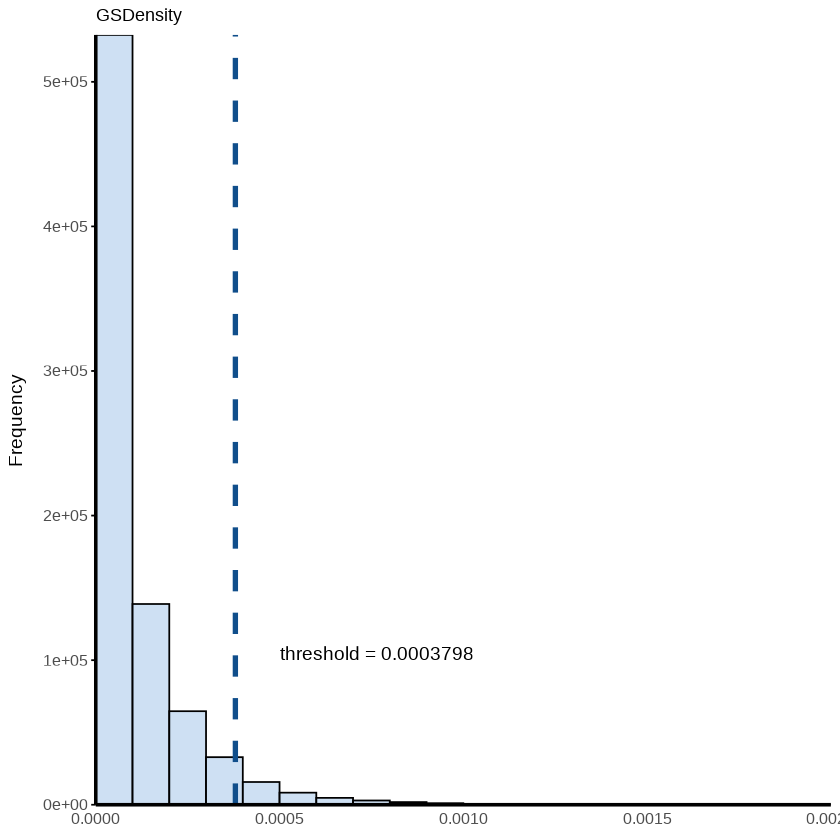

In [5]:
GSDensity_all=melt(GSDensity)
threshold = quantile(GSDensity_all$value, 0.95)
FigGSDensity <- ggplot(GSDensity_all, aes(x = value)) +
                  geom_histogram(aes(y = after_stat(count)), 
                                 binwidth = 0.0001,  
                                 boundary = 0,
                                 fill = "slategray2", 
                                 color = "black", 
                                 alpha = 0.7, 
                                 position = "identity") + 
                  scale_x_continuous(expand = c(0, 0)) +  
                  scale_y_continuous(expand = c(0, 0)) + 
                  labs(title = "GSDensity", x = NULL, y = "Frequency") + 
                  annotate("text", x = 0.0005, y = 1e+05, label = paste0("threshold = ", signif(threshold, 4)), hjust = 0, vjust = 0, color = "black", size = 5) + 
                  geom_vline(xintercept = threshold, color = "dodgerblue4", linetype = "dashed", linewidth = 1.5) +
                  theme_minimal() +  
                  theme(
                    axis.ticks.y = element_line(color = "black"), 
                    panel.grid = element_blank(),  
                    axis.title = element_text(size = 14),  
                    axis.text = element_text(size = 12),   
                    axis.line = element_line(linewidth = 1)     
                  )
FigGSDensity

No id variables; using all as measure variables

Warning message:
“Removed 39422 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_bar()`).”


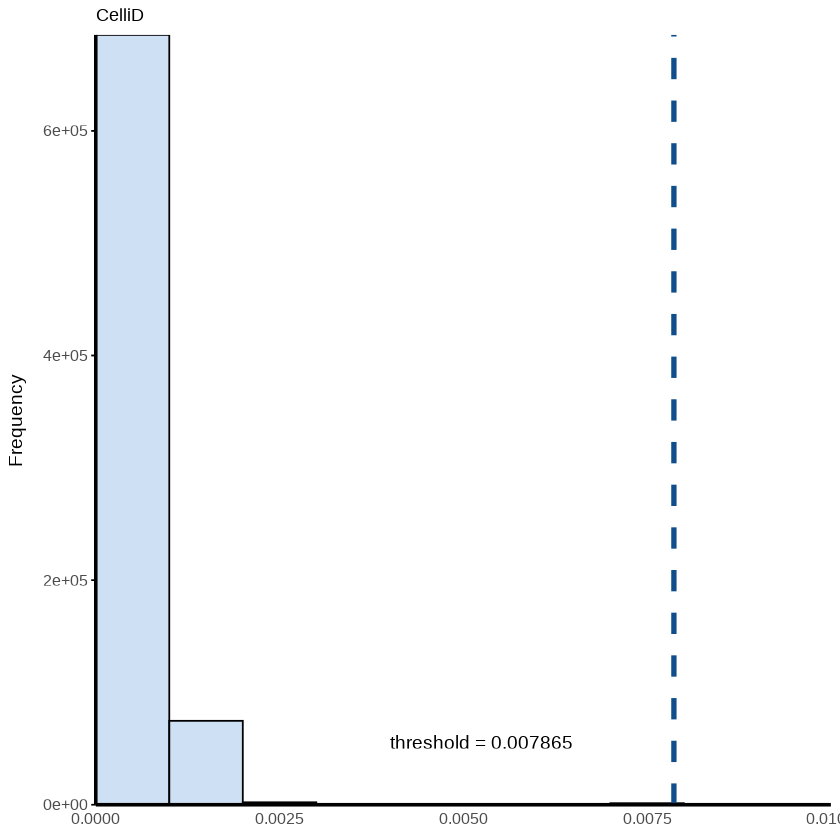

In [6]:
CelliD_all=melt(CelliD)
threshold = quantile(CelliD_all$value, 0.95)

FigCelliD <- ggplot(CelliD_all, aes(x = value)) +
              geom_histogram(aes(y = after_stat(count)),binwidth = 0.001, boundary = 0, fill = "slategray2", color = "black",alpha = 0.7, 
                             position = "identity") +
              scale_x_continuous(expand = c(0, 0),limits = c(0,0.01)) + 
              scale_y_continuous(expand = c(0, 0))+
              labs(title = 'CelliD', x = NULL, y = "Frequency") + 
              annotate("text", x = 0.004, y = 50000, label = paste0("threshold = ", signif(threshold, 4)), hjust = 0, vjust = 0, color = "black", size = 5) + 
              geom_vline(xintercept = threshold, color = "dodgerblue4", linetype = "dashed", linewidth = 1.5) +
              theme_minimal() +  
              theme(
                    axis.ticks.y = element_line(color = "black"), 
                    panel.grid = element_blank(),  
                    axis.title = element_text(size = 14),  
                    axis.text = element_text(size = 12),   
                    axis.line = element_line(linewidth = 1)     
              ) 
FigCelliD

Warning message:
“Removed 1082 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 1082 rows containing non-finite outside the scale range (`stat_density()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_bar()`).”
Warning message:
“Removed 39422 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_bar()`).”


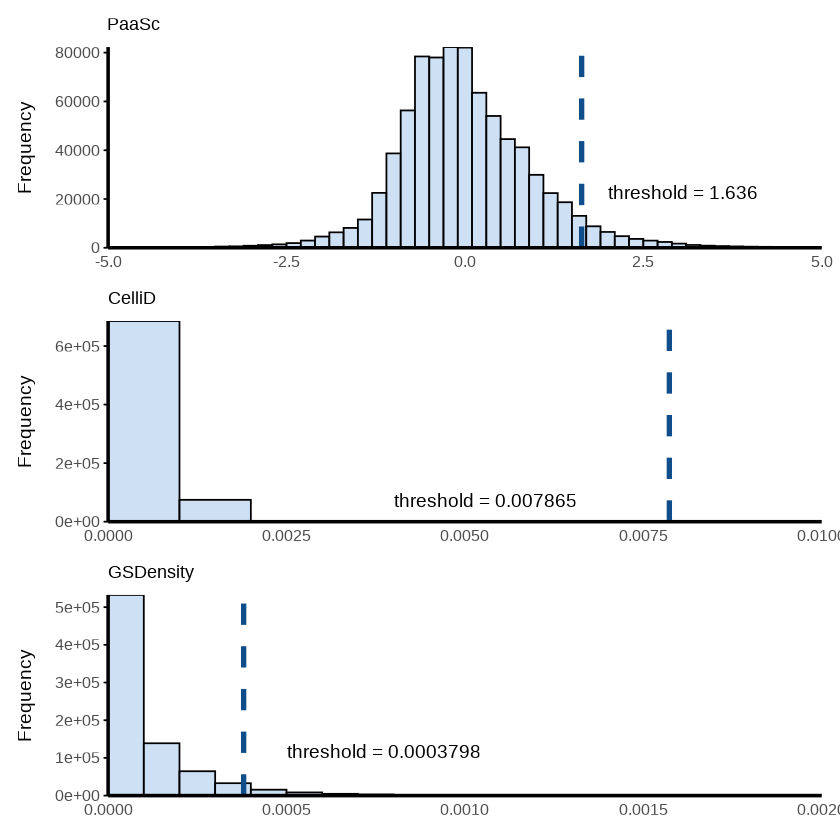

In [7]:
supFig5B<-(FigPaaSc / FigCelliD / FigGSDensity)
supFig5B